<h1 align=left><font size = 6>Train and Evaluate a Keras-Based Classifier </font></h1>


<h2>Objective</h2>

<ul> 
    
1. Create a Keras-based convolutional neural network (CNN) model.
2. Train the CNN model on agricultural and non-agricultural land dataset.
3. Evaluate the performance of the CNN model. 
    
</ul> 


## Introduction

This notebook demonstrates the process of building, training, and evaluating a **Keras-based convolutional neural network (CNN)** for image classification, for agricultural images in our case. This lab will cover the following:
1. Data preparation
2. Model architecture definition
3. Training
4. Model performance analysis.

The goal is to classify satellite images into two categories: "agricultural" and "non-agricultural"


## Table of Contents
<font size = 3> 

1. [Configuration and library imports](#Configuration-and-library-imports)
2. [Data acquisition and preparation](#Data-acquisition-and-preparation)
3. [Model definition and compilation](#Model-definition-and-compilation)
4. [Model training](#Model-training)
5. [Download and save the model](#Download-and-save-the-trained-model)
6. [Model evaluation and visualization](#Model-evaluation-and-visualization)

</font>


<hr>

In [1]:
%%time
%%capture captured_output

UsageError: %%capture is a cell magic, but the cell body is empty.


### Import libraries


Import the non-AI libraries. 


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import os
import sys
import time
import shutil
import random
import numpy as np
import skillsnetwork
from tqdm import tqdm
import matplotlib.pyplot as plt

### TensorFlow environment configuration

This cell sets environment variables for TensorFlow. 
- `TF_ENABLE_ONEDNN_OPTS` is set to "0" to disable Intel oneDNN optimizations, which can sometimes lead to issues or unwanted behavior on specific hardware configurations.
- `TF_CPP_MIN_LOG_LEVEL` is set to "2," instructing TensorFlow to only display warning and error messages from its C++ backend. This reduces verbose output and keeps the console cleaner, focusing on more critical information during model training.


In [4]:
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [9]:
from pathlib import Path

# Define directories and download the data
project_root = Path.cwd().parents[3]

Next, set up the data extraction directory.


In [10]:
# Define directories
base_dir = project_root / "data" / "images_dataSAT"

dir_non_agri = base_dir / "class_0_non_agri"
dir_agri = base_dir / "class_1_agri"

In [11]:
# Initialize empty lists to store paths and labels
all_image_paths = []
all_labels = []

# define the labels for each class
label_non_agri = 0
label_agri = 1

# populate the lists

for fname in os.listdir(dir_non_agri):
    all_image_paths.append(os.path.join(dir_non_agri, fname))
    all_labels.append(label_non_agri)

for fname in os.listdir(dir_agri):
    all_image_paths.append(os.path.join(dir_agri, fname))
    all_labels.append(label_agri)

In [12]:
## You can use this cell to type the code to answer the question.
# Use zip to bind paths and labels, then shuffle this list of pairs
temp = list(zip(all_image_paths, all_labels))
np.random.shuffle(temp)
all_image_paths, all_labels = zip(*temp)

print("First 5 paths and labels (after shuffling):", list(zip(all_image_paths[:5], all_labels[:5])))

First 5 paths and labels (after shuffling): [('/Users/abhisheksingh/Documents/Al and Cloud/ML & AI Engineering/Deep Learning/Projects with Deep Learning/data/images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_7287.jpg', 1), ('/Users/abhisheksingh/Documents/Al and Cloud/ML & AI Engineering/Deep Learning/Projects with Deep Learning/data/images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_6131.jpg', 1), ('/Users/abhisheksingh/Documents/Al and Cloud/ML & AI Engineering/Deep Learning/Projects with Deep Learning/data/images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_3734.jpg', 1), ('/Users/abhisheksingh/Documents/Al and Cloud/ML & AI Engineering/Deep Learning/Projects with Deep Learning/data/images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_10637.jpg', 1), ('/Users/abhisheksingh/Documents/Al and Cloud/

### Import deep learning and ML libraries

Here is a brief description of the usage of the **Keras** libraries and methods that will be used:
- `Sequential` models are a linear stack of layers.
- `Conv2D` and `MaxPooling2D` are fundamental for CNNs, extracting features and reducing dimensionality.
- `BatchNormalization` stabilizes training.
- `Dense` layers form the classifier.
- `Dropout` regularizes to prevent overfitting.
- `Adam` is an adaptive learning rate optimizer.
- `ImageDataGenerator` automates data loading and augmentation.
- `HeUniform` is used for weight initialization.


**Scikit-learn** (`sklearn.metrics`) provides the following metrics for model performance assessment: 
- `classification_report`
- `confusion_matrix`
- `accuracy_score`


In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.initializers import HeUniform
from tensorflow.keras.callbacks import ModelCheckpoint

from sklearn.metrics import accuracy_score
print("Succesfully imported the libraries")

Succesfully imported the libraries


### Get the processing device
Check the availability of GPU


In [14]:
gpu_list = tf.config.list_physical_devices('GPU')

device = "gpu" if gpu_list !=[] else "cpu"
print(f"Device available for training: {device}")

Device available for training: cpu


### Reproducibility with random seeds

Here we fix the random seeds for `random` module, NumPy, and TensorFlow. By initializing these seeds with a constant value (for example, 42), any operations that involve randomness (such as weight initialization, data shuffling, or data augmentation) will produce the exact same sequence of random numbers every time the code is run. This is crucial for ensuring the reproducibility of experimental results and when comparing different models or hyperparameters.


In [15]:
# Set seed for reproducibility
seed_value = 7331
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

### Define the dataset path


In [21]:
# dataset_path = os.path.join(extract_dir, "images_dataSAT")
# print(dataset_path)
dataset_path = str(base_dir)
print(dataset_path)

/Users/abhisheksingh/Documents/Al and Cloud/ML & AI Engineering/Deep Learning/Projects with Deep Learning/data/images_dataSAT


### Create the dataset file list


Now that we have downloaded the dataset, perform the following task. 


### **Task 1:** Recursively walk through the `dataset_path` using `os.walk` function to create a list **`fnames`** of all image files. 
Print the total count of files found and displays the first two and last two file paths. 

Absolute path is captured using `os.path.join(dirname, filename)` and used in `ImageDataGenerator` later.


In [22]:
## You can use this cell to type the code to complete the task.
fnames = []
for dirname, _, filenames in os.walk(dataset_path):
    for filename in filenames:
        fnames.append(os.path.join(dirname, filename))
print(f"total files in dataset: {len(fnames)}")
nfname_print=2
for f in fnames[:nfname_print]:
    print(f)
for f in fnames[-nfname_print:]:
    print(f)

total files in dataset: 6000
/Users/abhisheksingh/Documents/Al and Cloud/ML & AI Engineering/Deep Learning/Projects with Deep Learning/data/images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_5974.jpg
/Users/abhisheksingh/Documents/Al and Cloud/ML & AI Engineering/Deep Learning/Projects with Deep Learning/data/images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_23339.jpg
/Users/abhisheksingh/Documents/Al and Cloud/ML & AI Engineering/Deep Learning/Projects with Deep Learning/data/images_dataSAT/class_0_non_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_15163.jpg
/Users/abhisheksingh/Documents/Al and Cloud/ML & AI Engineering/Deep Learning/Projects with Deep Learning/data/images_dataSAT/class_0_non_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_8291.jpg


### Define the model hyperparameters

Hyperparameters are configurable values that are set before the training process begins. 

This cell initializes several key hyperparameters that will govern the training process and the model's input. Here is the list of hyperparameters:

1. `img_w` and `img_h` define the width and height for resizing input images.
2. `n_channels` defines the number of color channels (3 for RGB).
3. `n_epochs` sets the total training iterations over the dataset.
4. `batch_size` sets the number of samples processed per batch in the epoch.
5. `lr` defines the learning rate for the optimizer.
6. `steps_per_epoch` are total number of steps used for training. **None** means the number is calculated automatically.
7. `validation_steps` are total number of steps used for validating the model on validation data. **None** means the number is calculated automatically.

These hyperparameters are crucial for controlling model performance and resource utilization and significantly influence a model's performance and training efficiency. 


In [18]:
img_w, img_h = 64, 64
n_channels = 3
batch_size = 128
lr = 0.001 # Learning rate
n_epochs = 3 # set to low number for your convenience. You can change this to any number of your liking

steps_per_epoch = None
validation_steps = None 

model_name = "ai_capstone_keras_best_model.model.keras"

### Configure `ImageDataGenerator` for Augmentation


Now, we instantiate the `ImageDataGenerator` with data augmentation parameters:

- `rescale=1./255` normalizes pixel values to [0, 1].
- `rotation_range`, `width_shift_range`, `height_shift_range`, `shear_range`, and `zoom_range` define random transformations to apply to images during training, increasing dataset diversity.
- `horizontal_flip=True` enables random horizontal mirroring.
- `fill_mode='nearest'` specifies how new pixels are filled after transformations.
- `validation_split=0.2` reserves 20% of data for validation.


This setup boosts model robustness against variations in real-world images. `ImageDataGenerator` performs these transformations on-the-fly, making it efficient for large datasets. 


In [19]:
datagen = ImageDataGenerator(rescale=1./255,
                             rotation_range=40, 
                             width_shift_range=0.2,
                             height_shift_range=0.2,
                             shear_range=0.2,
                             zoom_range=0.2,
                             horizontal_flip=True,
                             fill_mode="nearest",
                             validation_split=0.2
                            )

### Create training and validation data generators

 `ImageDataGenerator` is used to create `train_generator` and `validation_generator`. 
`flow_from_directory()` is a convenient method of `ImageDataGenerator` for automatically creating data pipelines from structured image directories.
 The generator resize images to `(img_w, img_h)` and group them into `batch_size` chunks. `class_mode="binary"` indicates a two-class classification task. 
 
 The `subset` parameter is used to assign 80% of the data for training and 20% for validation based on the `validation_split`. 


In [23]:
train_generator = datagen.flow_from_directory(dataset_path,
 target_size = (img_w, img_h),
 batch_size= batch_size,
 class_mode="binary",
 subset="training"
 )

Found 4800 images belonging to 2 classes.


Here is your next task. We have created the `train_generator`, let's create the `validation_generator`.


### Creating the `validation_generator` from `dataset_path`.
Use `target_size`, and `class_mode` similar to `train_generator`.


In [24]:
## You can use this cell to type the code to complete the task.
validation_generator = datagen.flow_from_directory(dataset_path,
                                                    target_size =(img_w, img_h),
                                                    batch_size = batch_size, 
                                                    class_mode="binary",
                                                    subset="validation"
                                                    )

Found 1200 images belonging to 2 classes.


## Model definition and compilation

### Define the convolutional neural network (CNN) architecture

The model architecture is composed of several key components:
- **`Sequential`** is a linear stack of layers in Keras.
- **Conv2D** layers perform convolution operations, acting as feature detectors.
- **MaxPooling2D** reduces the spatial dimensions of the feature maps.
-  **BatchNormalization** normalizes layer inputs, stabilizing and accelerating training.
-  **GlobalAveragePooling2D** summarizes feature maps into a single vector, reducing parameters.
-  **Dense** (fully connected) layers learn complex patterns from these features.
-  **Dropout** is a regularization technique that randomly deactivates neurons during training.
-  **Sigmoid** activation is used for binary classification, mapping outputs to probabilities.
-  **HeUniform** initializer is suitable for ReLU activations.
-  **The final output `Dense` layer** uses a `sigmoid` activation for binary classification, outputting a probability between 0 and 1.


In [25]:
model = Sequential([
                    Conv2D(32 , (5,5) , activation="relu",padding="same",strides=(1,1), kernel_initializer=HeUniform(), input_shape=(img_w, img_h, n_channels)),
                    MaxPooling2D(2,2),
                    BatchNormalization(),
                    
                    Conv2D(64, (5,5) , activation="relu",padding="same" , strides=(1,1), kernel_initializer=HeUniform()),
                    MaxPooling2D(2,2),
                    BatchNormalization(),
                    
                    Conv2D(128, (5,5) , activation="relu",padding="same" ,strides=(1,1), kernel_initializer=HeUniform()),
                    MaxPooling2D(2,2),
                    BatchNormalization(),
                    
                    ###
                    Conv2D(256, (5,5) , activation="relu",padding="same" ,strides=(1,1), kernel_initializer=HeUniform()),
                    MaxPooling2D(2,2),
                    BatchNormalization(),
                    
                    Conv2D(512, (5,5) , activation="relu",padding="same" ,strides=(1,1), kernel_initializer=HeUniform()),
                    MaxPooling2D(2,2),
                    BatchNormalization(),
                    
                    Conv2D(1024, (5,5) , activation="relu",padding="same" ,strides=(1,1), kernel_initializer=HeUniform()),
                    MaxPooling2D(2,2),
                    BatchNormalization(),
                    
                    
                    ###
                    GlobalAveragePooling2D(),
                    
                    Dense(64,activation="relu" , kernel_initializer=HeUniform()),
                    BatchNormalization(),
                    Dropout(0.4),
                    
                    Dense(128,activation="relu" , kernel_initializer=HeUniform()),
                    BatchNormalization(),
                    Dropout(0.4),
                    
                    Dense(256,activation="relu" , kernel_initializer=HeUniform()),
                    BatchNormalization(),
                    Dropout(0.4),
                    
                    ###
                    Dense(512,activation="relu" , kernel_initializer=HeUniform()),
                    BatchNormalization(),
                    Dropout(0.4),
                    
                    Dense(1024,activation="relu" , kernel_initializer=HeUniform()),
                    BatchNormalization(),
                    Dropout(0.4),
                    
                    Dense(2048,activation="relu" , kernel_initializer=HeUniform()),
                    BatchNormalization(),
                    Dropout(0.4),
                    
                    
                    ###
                    Dense(1 , activation="sigmoid")
                    
                ])

### Compile the model and display the summary


Here, we compile the model using `model.compile()` with the `Adam` optimizer and `learning_rate` equal to `lr` (0.001). 

The `loss` function is specified as `"binary_crossentropy"`, appropriate for binary classification problems. 
`accuracy` is set as the performance `metric` to monitor training and evaluation. 
We print `model.summary()` for a detailed overview of the network


In [26]:
loss = "binary_crossentropy"
model.compile(optimizer=Adam(learning_rate=lr),
              loss=loss, 
              metrics=["accuracy"])

print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 64, 64, 32)        2432      
                                                                 
 max_pooling2d (MaxPooling2  (None, 32, 32, 32)        0         
 D)                                                              
                                                                 
 batch_normalization (Batch  (None, 32, 32, 32)        128       
 Normalization)                                                  
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 64)        51264     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 16, 16, 64)        0         
 g2D)                                                            
                                                        

Answer the question below in the space provided. 


## Counting the total number of layers in this CNN model?


There are total 38 layers.

You now know how to create a CNN model using Keras. You can perform the following task. 


## Creating and compile a CNN model `test_model` with 4 Conv2D layers and 5 Dense layers.


In [27]:
## You can use this cell to type the code to complete the task.
model = Sequential([
 Conv2D(32 , (5,5) , activation="relu",padding="same",strides=(1,1), kernel_initializer=HeUniform(), input_shape=(img_w, img_h, n_channels)),
 MaxPooling2D(2,2),
 BatchNormalization(),

 Conv2D(64, (5,5) , activation="relu",padding="same" , strides=(1,1), kernel_initializer=HeUniform()),
 MaxPooling2D(2,2),
 BatchNormalization(),

 Conv2D(128, (5,5) , activation="relu",padding="same" ,strides=(1,1), kernel_initializer=HeUniform()),
 MaxPooling2D(2,2),
 BatchNormalization(),
 
###
 Conv2D(256, (5,5) , activation="relu",padding="same" ,strides=(1,1), kernel_initializer=HeUniform()),
 MaxPooling2D(2,2),
 BatchNormalization(),
 
###
 GlobalAveragePooling2D(),

 Dense(64,activation="relu" , kernel_initializer=HeUniform()),
 BatchNormalization(),
 Dropout(0.4),

 Dense(128,activation="relu" , kernel_initializer=HeUniform()),
 BatchNormalization(),
 Dropout(0.4),

 Dense(256,activation="relu" , kernel_initializer=HeUniform()),
 BatchNormalization(),
 Dropout(0.4),

###
 Dense(512,activation="relu" , kernel_initializer=HeUniform()),
 BatchNormalization(),
 Dropout(0.4),

###
 Dense(1 , activation="sigmoid")
 
 ])

# Compile the model to make it ready for training
loss = "binary_crossentropy"
model.compile(optimizer=Adam(learning_rate=lr),loss=loss, metrics=["accuracy"])

## Model training

### Display the training configuration and hyperparameters

Here we print a comprehensive summary of the training configuration and list all critical hyperparameters. This detailed output serves as a quick reference and verification of the experimental setup.
Before commencing computationally intensive tasks such as deep learning model training, it's a good practice to log and verify the configuration.


In [28]:
print(f"Training Hyperparameters:\n\
        n_classes (train) = {train_generator.num_classes},\n\
        n_classes (validation) = {validation_generator.num_classes},\n\
        img_w, img_h ={img_w, img_h},\n\
        n_channels = {n_channels},\n\
        batch_size = {batch_size},\n\
        steps_per_epoch = {steps_per_epoch},\n\
        n_epochs = {n_epochs},\n\
        validation_steps = {validation_steps},\n\
        learning_rate = {lr}")

Training Hyperparameters:
        n_classes (train) = 2,
        n_classes (validation) = 2,
        img_w, img_h =(64, 64),
        n_channels = 3,
        batch_size = 128,
        steps_per_epoch = None,
        n_epochs = 3,
        validation_steps = None,
        learning_rate = 0.001


### Save the model checkpoint

Now we declare a method to save the **best model** during training. The best model can be defined by either **lowest loss** or **high accuracy**.


In [29]:
# Create the ModelCheckpoint callback
checkpoint_cb = ModelCheckpoint(filepath=model_name,
                                monitor='val_loss',      # or 'val_accuracy'
                                mode='min',              # 'min' for loss, 'max' for accuracy
                                save_best_only=True,
                                verbose=1
                               )

The checkpoint of a model can also be based on high accuracy. So, here's your next task.  


### Creating the checkpoint callback for model with **maximum accuracy**. 


In [30]:
## You can use this cell to type the code to complete the task.
checkpoint_cb = ModelCheckpoint(filepath=model_name,
                                monitor='val_accuracy',
                                mode='max',
                                save_best_only=True,
                                verbose=1
                               )

### Execute model training

- `model.fit()` is the primary function for training a Keras model. It controls the entire training loop: iterating over epochs, fetching data batches from generators, performing forward and backward passes, updating weights via the optimizer, and calculating loss and metrics.
- `steps_per_epoch` (*if specified*) determines how many batches constitute an "epoch."
- `validation_data` and `validation_steps` allow monitoring of the model's generalization ability on a separate dataset, helps in detecting overfitting.
- `callbacks` determines how the best model is saved.
- The `fit` object stores the model's training history.


In [31]:
print(f"Training on : ==={device}=== with batch size: {batch_size} & lr: {lr}")

fit = model.fit(train_generator, 
                epochs= n_epochs,
                steps_per_epoch = steps_per_epoch,
                validation_data=(validation_generator),
                validation_steps = validation_steps,
                callbacks=[checkpoint_cb],
                verbose=1
               )

Training on : ===cpu=== with batch size: 128 & lr: 0.001
Epoch 1/3
38/38 [==============================] - ETA: 0s - loss: 0.1974 - accuracy: 0.9185
Epoch 1: val_accuracy improved from -inf to 0.42417, saving model to ai_capstone_keras_best_model.model.keras
38/38 [==============================] - 23s 578ms/step - loss: 0.1974 - accuracy: 0.9185 - val_loss: 2.7835 - val_accuracy: 0.4242
Epoch 2/3
38/38 [==============================] - ETA: 0s - loss: 0.0626 - accuracy: 0.9804
Epoch 2: val_accuracy improved from 0.42417 to 0.47333, saving model to ai_capstone_keras_best_model.model.keras
38/38 [==============================] - 22s 591ms/step - loss: 0.0626 - accuracy: 0.9804 - val_loss: 2.6704 - val_accuracy: 0.4733
Epoch 3/3
38/38 [==============================] - ETA: 0s - loss: 0.0652 - accuracy: 0.9777
Epoch 3: val_accuracy improved from 0.47333 to 0.58833, saving model to ai_capstone_keras_best_model.model.keras
38/38 [==============================] - 23s 614ms/step - loss: 

## Model evaluation and visualization


### Perform a comprehensive model evaluation

Here, you will perform a detailed evaluation of the trained model on the validation dataset. You would calculate the necessary prediction `steps` based on the validation data and `batch_size`. Then, you will obtain the true class labels (`y_true`) and generate the model's predictions (`y_pred`) on the validation set. The predicted probabilities are converted to binary class labels using a 0.5 threshold. Finally, you will print the overall `accuracy_score`, to get a  quantitative assessment of the model's performance on unseen data.

Model evaluation metrics are essential for understanding a model's generalization ability. `y_true` represents the actual labels, while `y_pred` are the model's predicted labels. For binary classification, probabilities are converted to class labels by thresholding. The **accuracy score** is the proportion of correct predictions out of the total predictions.


In [27]:
steps = int(np.ceil(validation_generator.samples / validation_generator.batch_size))
batch_size = int(validation_generator.batch_size)

all_preds = []
all_labels = []
for step in range(steps):
    # Get one batch data
    images, labels = next(validation_generator)
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int).flatten() 
    all_preds.extend(preds)
    all_labels.extend(labels)
accuracy = accuracy_score(all_labels, all_preds)
print(f"Accuracy Score: {accuracy:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Accuracy Score: 0.5567


### Visualize the training history (accuracy and loss)


This cell generates two plots to visualize the model's training performance, one for accuracy and one for loss, across epochs. 
- **Accuracy** measures the proportion of correct predictions. 
- **Loss** quantifies the error between predictions and true labels. 
- Using these metrics, we can check the model for **overfitting** or **underfitting**. 
- `fit.history` attribute stores these metrics for each epoch.


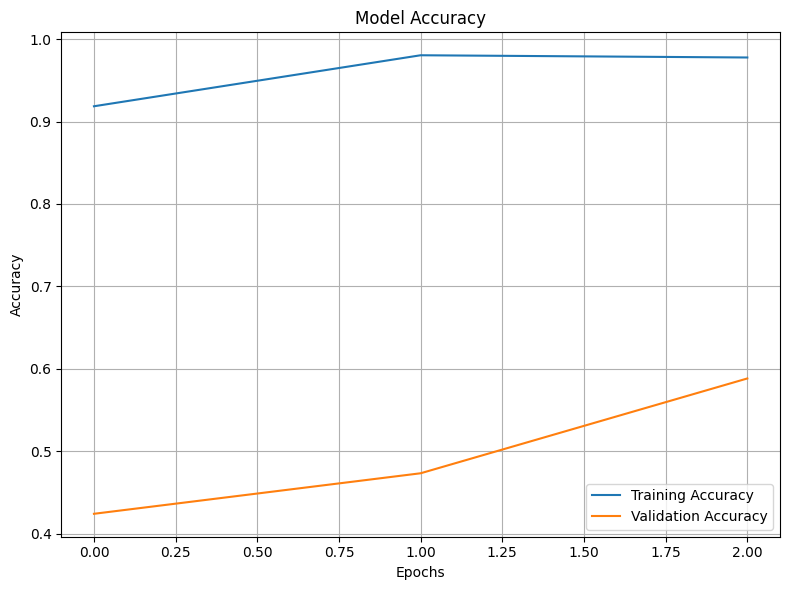

In [32]:
# Create a figure with a subplot
fig, axs = plt.subplots(figsize=(8, 6))

# Plot Accuracy on the first subplot
axs.plot(fit.history['accuracy'], label='Training Accuracy')
axs.plot(fit.history['val_accuracy'], label='Validation Accuracy')
axs.set_title('Model Accuracy')
axs.set_xlabel('Epochs')
axs.set_ylabel('Accuracy')
axs.legend()
axs.grid(True)

plt.tight_layout()
plt.show()

Plot the model loss in the task below. 


### Plotting the graph for **training loss** and **validation loss** for the model `fit`.


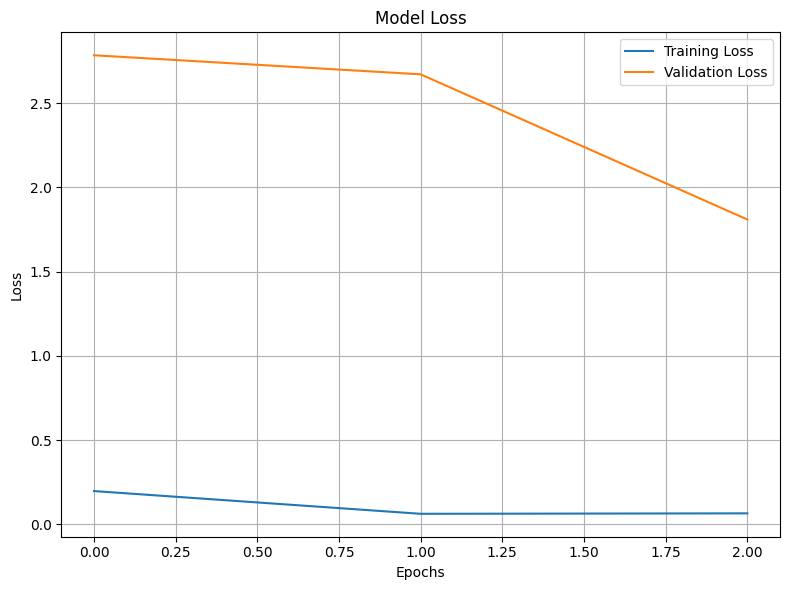

In [33]:
## You can use this cell to type the code to complete the task.
fig, axs = plt.subplots( figsize=(8, 6))


# Plot Loss on the second subplot
axs.plot(fit.history['loss'], label='Training Loss')
axs.plot(fit.history['val_loss'], label='Validation Loss')
axs.set_title('Model Loss')
axs.set_xlabel('Epochs')
axs.set_ylabel('Loss')
axs.legend()
axs.grid(True)

plt.tight_layout()
plt.show()

## Conclusion

- **Robust data handling:** We implemented a robust data acquisition strategy, featuring a primary method and a crucial fallback for reliable data downloading and extraction.
- **Reproducibility:** We used fixed random seeds ensures your results are consistent and verifiable across multiple runs.
- **Data generators:** We learnt about ImageDataGenerator for efficient on-the-fly image loading, resizing, normalization, and vital data augmentation.
- **CNN architecture:** We built a multi-layered CNN, incorporating Conv2D, MaxPooling2D, BatchNormalization, Dropout, and Dense layers for effective feature learning and classification.
- **Model compilation:** We configured the model's learning process with an Adam optimizer, binary_crossentropy loss, and accuracy metric.
- **Training process:** We executed the training loop, feeding data in batches and monitoring performance over epochs.
- **Performance visualization:** We plotted the accuracy and loss plots for understandinbg the model's learning progress and identify overfitting.
- **Model evaluation:** Finally, we use accuracy_score for a quantitative assessment of your model.
